# import

In [72]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


# 乱数の固定

In [73]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True


# （可能なら）GPUの利用

In [74]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# 汎用関数の定義

## func show_images_labels

In [75]:
# イメージとラベル表示
def show_images_labels(loader, classes, net, device):
    # データローダーから最初の1セットを取得する
    for images, labels in loader:
        break
    # 表示数は50個とバッチサイズのうち小さい方
    n_size = min(images.size(0), 50)

    if net is not None:
        # デバイスの割り当て
        inputs = images.to(device)
        labels = labels.to(device)

      # 予測計算
        outputs = net(inputs)
        predicted = torch.max(outputs,1)[1]
        #images = images.to('cpu')

    # 最初のn_size個の表示
    plt.figure(figsize=(20, 15))
    for i in range(n_size):
        ax = plt.subplot(5, 10, i + 1)
        label_name = classes[labels[i]]
        # netがNoneでない場合は、予測結果もタイトルに表示する
        if net is not None:
            predicted_name = classes[predicted[i]]
            # 正解かどうかで色分けをする
            if label_name == predicted_name:
                c = 'g'
            else:
                c = 'r'
            ax.set_title(label_name + ':' + predicted_name, c=c, fontsize=20)
        # netがNoneの場合は、正解ラベルのみ表示
        else:
            ax.set_title(label_name, fontsize=20)
        # TensorをNumPyに変換
        image_np = images[i].numpy().copy()
        #print(image_np.shape)
        # 軸の順番変更 (channel, row, column) -> (row, column, channel)
        img = np.transpose(image_np, (1, 2, 0))
        # 値の範囲を[-1, 1] -> [0, 1]に戻す
        img = (img + 1)/2
        # 結果表示
        plt.imshow(img)
        ax.set_axis_off()
    plt.show()


## func evaluate_history

In [76]:
def evaluate_history(history):
    print(f'初期状態: 損失: {history[0, 3]:.5f} 精度: {history[0, 4]:.5f}') 
    print(f'最終状態: 損失: {history[-1, 3]:.5f} 精度: {history[-1, 4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    plt.figure(figsize=(9, 8))
    plt.plot(history[:, 0], history[:, 1], 'r', label='train')
    plt.plot(history[:, 0], history[:, 3], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Learning Curve (Loss)')
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(9,8))
    plt.plot(history[:, 0], history[:, 2], 'r', label='train')
    plt.plot(history[:, 0], history[:, 4], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Learning Curve (Accuracy)')
    plt.grid()
    plt.legend()
    plt.show()


## func fit

In [77]:
def fit(num_epochs, net, criterion, optimizer, train_loader, valid_loader, device, history):
    pbar = tqdm(range(num_epochs), leave=True)

    for epoch in pbar:
        train_loss, train_acc, n_train = 0, 0, 0
        valid_loss, valid_acc, n_valid = 0, 0, 0

        # 訓練フェーズ
        net.train()
        for images, labels in train_loader:
            batch_size = images.size(0)
            n_train += batch_size

            inputs = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # 勾配の初期化
            outputs = net(inputs) # 予測計算
            loss = criterion(outputs, labels) # 損失計算
            loss.backward() # 勾配計算
            optimizer.step() # パラメータ更新

            train_loss += loss.item() * batch_size # 損失はバッチサイズで平均されているため戻しておく．
            _, indices = torch.max(outputs, dim=1)
            train_acc += (indices == labels).sum().item()

        # 検証フェーズ
        net.eval()
        with torch.no_grad():
            for images, labels in valid_loader:
                batch_size = images.size(0)
                n_valid += batch_size

                inputs = images.to(device)
                labels = labels.to(device)

                outputs = net(inputs) # 予測計算
                loss = criterion(outputs, labels) # 損失計算

                valid_loss += loss.item() * batch_size # 損失はバッチサイズで平均されているため戻しておく．
                _, indices = torch.max(outputs, dim=1)
                valid_acc += (indices == labels).sum().item()

        # 記録フェーズ
        train_loss /= n_train
        train_acc /= n_train

        valid_loss /= n_valid
        valid_acc /= n_valid

        pbar.set_postfix({
            'train_loss': f"{train_loss:.4f}",
            'train_acc': f"{train_acc:.4f}",
            'valid_loss': f"{valid_loss:.4f}",
            'valid_acc': f"{valid_acc:.4f}"
        })

        item = np.array([epoch, train_loss, train_acc, valid_loss, valid_acc])
        history = np.vstack((history, item))
    
    return history


# データ準備

## Transformsの定義

In [78]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])


## データセットの定義

In [79]:
data_root = './data'

# 元になるデータセット
train_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)
valid_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=eval_transform)

train_size = int(len(train_set_full) * 0.9)

# データを分割するためのランダムなインデックスを生成
indices = torch.randperm(len(train_set_full)).tolist()

train_set = Subset(train_set_full, indices[:train_size])
valid_set = Subset(valid_set_full, indices[train_size:])
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=eval_transform)

print(len(train_set))
print(len(valid_set))
print(len(test_set))


45000
5000
10000


## データローダーの定義

In [80]:
# from torch.utils.data import Dataloader

train_loader = DataLoader(train_set, batch_size=64, shuffle=True) # 小さめのバッチサイズで過学習の防止を期待する．
valid_loader = DataLoader(valid_set, batch_size=256, shuffle=False)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

# データローダーから先頭のミニバッチを取得してみる．
for loader in [train_loader, valid_loader, test_loader]:
    for images, labels in loader:
        print(f"images.shape: {images.shape}, labels.shape: {labels.shape}")
        break


images.shape: torch.Size([64, 3, 32, 32]), labels.shape: torch.Size([64])
images.shape: torch.Size([256, 3, 32, 32]), labels.shape: torch.Size([256])
images.shape: torch.Size([256, 3, 32, 32]), labels.shape: torch.Size([256])


## 正解ラベルの変換規則

In [81]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## 最初の50個の表示

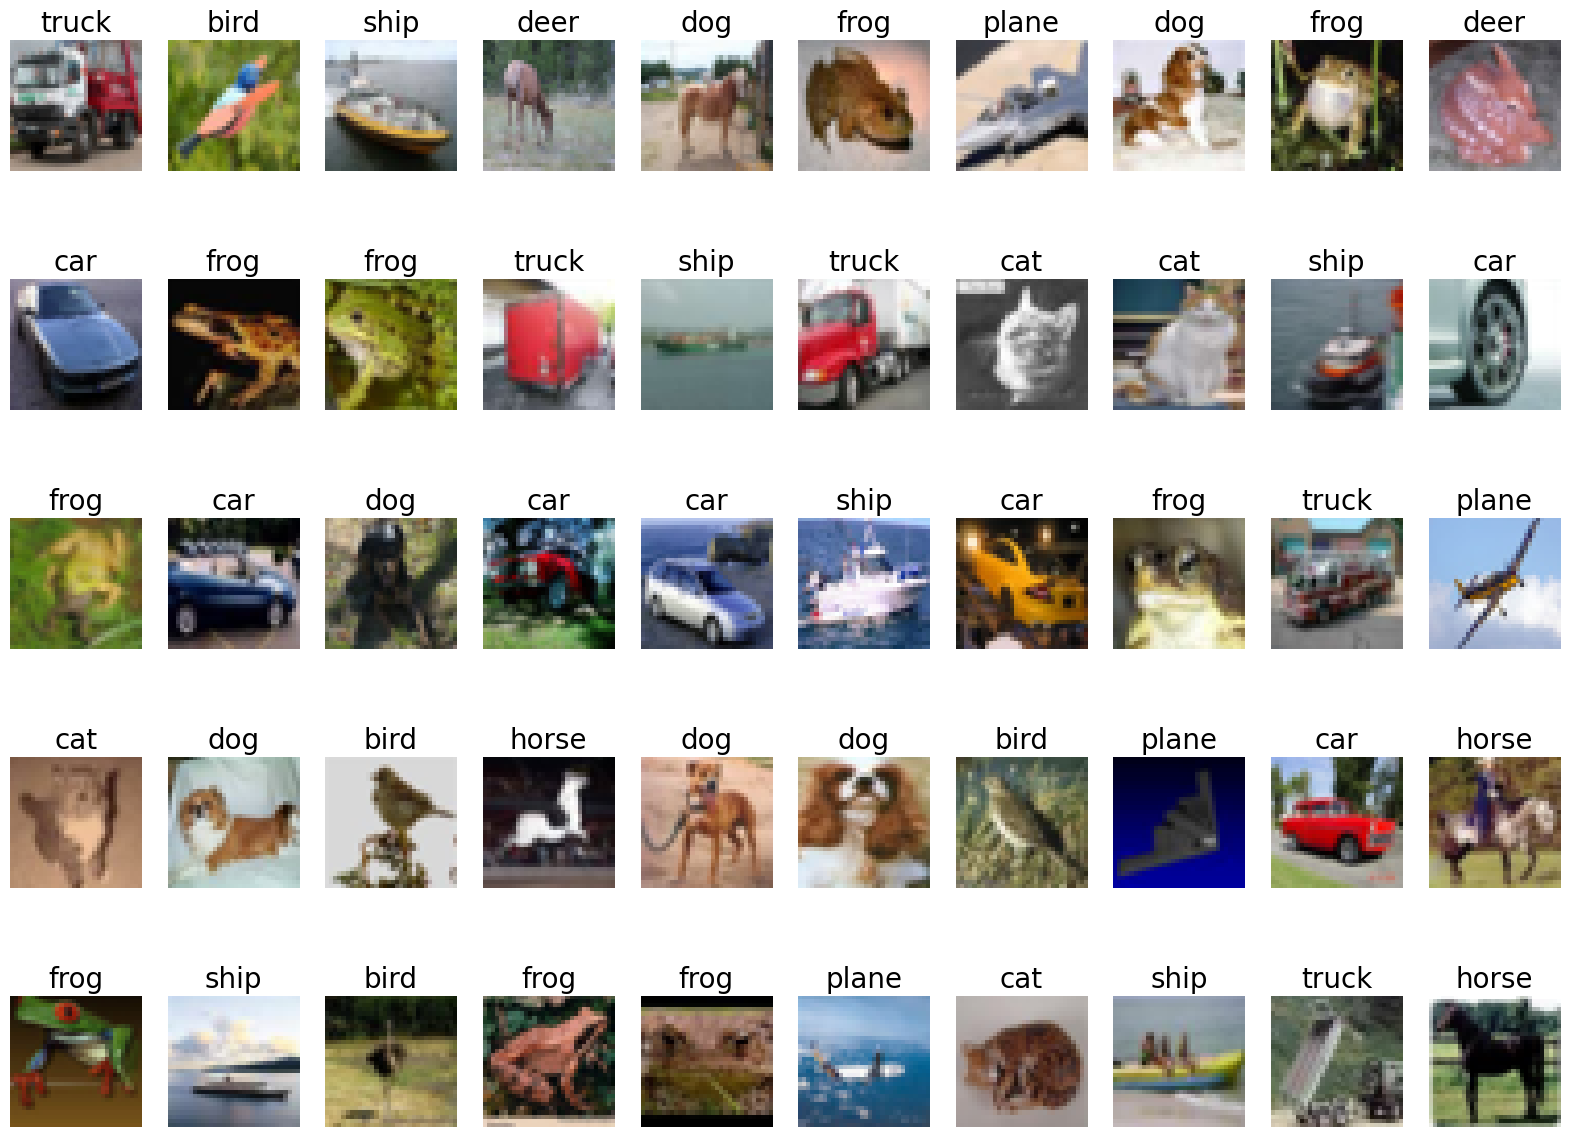

In [82]:
show_images_labels(train_loader, classes, None, None)


# 階層を深くしたモデル（CNN_v2）

## モデル定義

In [83]:
class CNN_v2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=(1, 1))
        self.conv2 = nn.Conv2d(32, 32, 3, padding=(1, 1))
        self.conv3 = nn.Conv2d(32, 64, 3, padding=(1, 1))
        self.conv4 = nn.Conv2d(64, 64, 3, padding=(1, 1))
        self.conv5 = nn.Conv2d(64, 128, 3, padding=(1, 1))
        self.conv6 = nn.Conv2d(128, 128, 3, padding=(1, 1))
        self.relu = nn.ReLU(inplace=True) # ReLUの微分は，0か1しか無いため，中間テンソルの記録をしない．
        self.flatten = nn.Flatten()
        self.maxpool = nn.MaxPool2d((2, 2))
        self.l1 = nn.Linear(4*4*128, 128)
        self.l2 = nn.Linear(128, num_classes)

        self.features = nn.Sequential(
            self.conv1,
            self.relu,
            self.conv2,
            self.relu,
            self.maxpool,
            self.conv3,
            self.relu,
            self.conv4,
            self.relu,
            self.maxpool,
            self.conv5,
            self.relu,
            self.conv6,
            self.relu,
            self.maxpool
        )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.l2
        )
    
    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3


## 学習の初期設定

In [84]:
num_epochs = 50
net = CNN_v2(num_classes=len(classes)).to(device)
criterion = nn.CrossEntropyLoss()
lr = 0.01
optimizer = optim.SGD(net.parameters(), lr=lr)
history = np.zeros((0, 5))


## 学習ループ

In [ ]:
history = fit(num_epochs, net, criterion, optimizer, train_loader, valid_loader, device, history)


 10%|█         | 5/50 [01:34<14:12, 18.95s/it, train_loss=2.0751, train_acc=0.2356, valid_loss=2.2013, valid_acc=0.2032]

## 評価

In [ ]:
evaluate_history(history)


IndexError: index 0 is out of bounds for axis 0 with size 0